In [11]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [12]:
Data = pd.read_csv('/home/omnix/Desktop/Google_Playstore/Google-Playstore-EDA/Data/Cleaned_Data.csv')

In [13]:
# Remove Installs from its current position and append to end
cols = [col for col in Data.columns if col != 'Installs'] + ['Installs']
Data = Data[cols]

print(Data.columns.tolist())
print(Data.shape)

['App', 'Rating', 'Reviews', 'Size', 'Price', 'Content Rating', 'Subscription_Type', 'Year', 'Month', 'Day', 'Application_Type', 'Android_version', 'Primary_Application_Type', 'Installs']
(9462, 14)


In [14]:
Data


,App,Rating,Reviews,Size,Price,Content Rating,Subscription_Type,Year,Month,Day,Application_Type,Android_version,Primary_Application_Type,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,19000.0,0.0,Everyone,0,2018,1,7,Art & Design,4.0.3 and up,Art & Design,10000
1,Coloring book moana,3.9,967,14000.0,0.0,Everyone,0,2018,1,15,Art & Design;Pretend Play,4.0.3 and up,Art & Design,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,8.7,0.0,Everyone,0,2018,8,1,Art & Design,4.0.3 and up,Art & Design,5000000
3,Sketch - Draw & Paint,4.5,215644,25000.0,0.0,Teen,0,2018,6,8,Art & Design,4.2 and up,Art & Design,50000000
4,Pixel Draw - Number Art Coloring Book,4.3,967,2.8,0.0,Everyone,0,2018,6,20,Art & Design;Creativity,4.4 and up,Art & Design,100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9457,FR Calculator,4.0,7,2.6,0.0,Everyone,0,2017,6,18,Education,4.1 and up,Education,500
9458,FR Forms,4.3,0,9.6,0.0,Everyone,0,2016,9,29,Business,4.0 and up,Business,10
9459,Sya9a Maroc - FR,4.5,38,53000.0,0.0,Everyone,0,2017,7,25,Education,4.1 and up,Education,5000
9460,Fr. Mike Schmitz Audio Teachings,5.0,4,3.6,0.0,Everyone,0,2018,7,6,Education,4.1 and up,Education,100


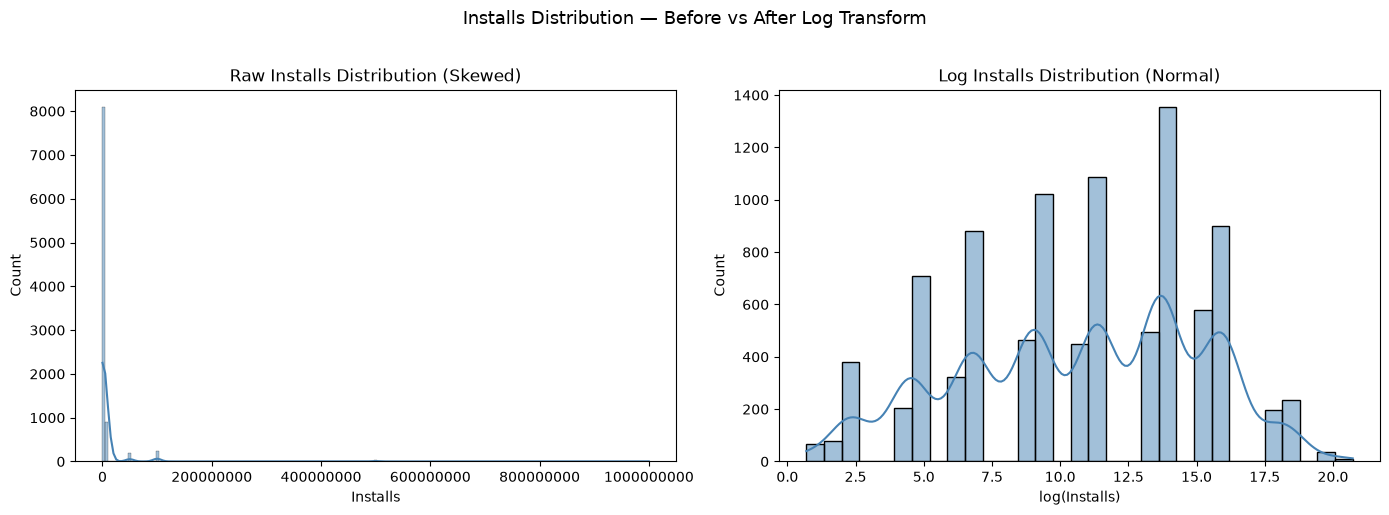

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Raw (skewed)
sns.histplot(Data['Installs'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Raw Installs Distribution (Skewed)')
axes[0].set_xlabel('Installs')
axes[0].ticklabel_format(style='plain', axis='x')

# Right — Log transformed (readable)
sns.histplot(np.log1p(Data['Installs']), kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Log Installs Distribution (Normal)')
axes[1].set_xlabel('log(Installs)')

plt.suptitle('Installs Distribution — Before vs After Log Transform', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9462 entries, 0 to 9461
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   App                       9462 non-null   str    
 1   Rating                    9462 non-null   float64
 2   Reviews                   9462 non-null   int64  
 3   Size                      9462 non-null   float64
 4   Price                     9462 non-null   float64
 5   Content Rating            9462 non-null   str    
 6   Subscription_Type         9462 non-null   int64  
 7   Year                      9462 non-null   int64  
 8   Month                     9462 non-null   int64  
 9   Day                       9462 non-null   int64  
 10  Application_Type          9462 non-null   str    
 11  Android_version           9462 non-null   str    
 12  Primary_Application_Type  9462 non-null   str    
 13  Installs                  9462 non-null   int64  
dtypes: float64(3), int6

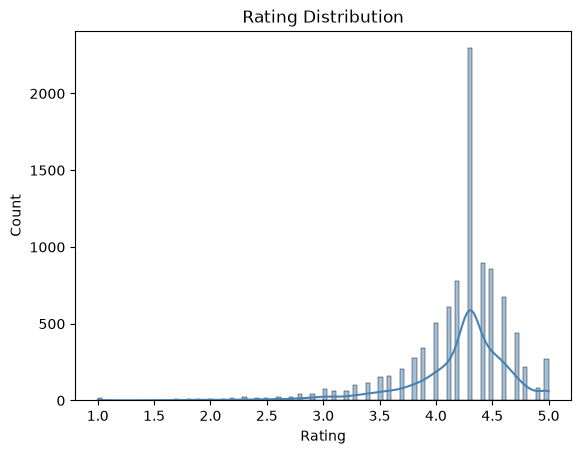

In [66]:
sns.histplot(Data['Rating'], kde=True, color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

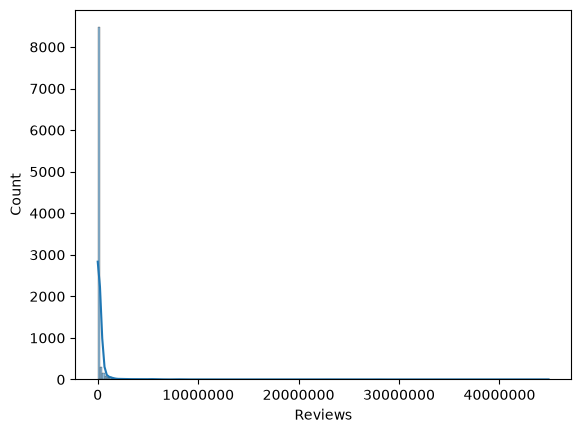

In [18]:
sns.histplot(Data['Reviews'],kde=True)
plt.ticklabel_format(style='plain',axis='x')

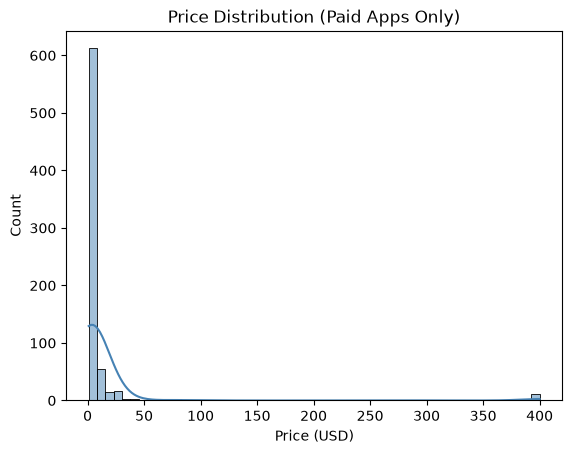

In [67]:
Sample_Data = Data[Data['Price'] > 0].copy()
sns.histplot(Sample_Data['Price'], kde=True, color='steelblue')
plt.title('Price Distribution (Paid Apps Only)')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Size in Kb ')

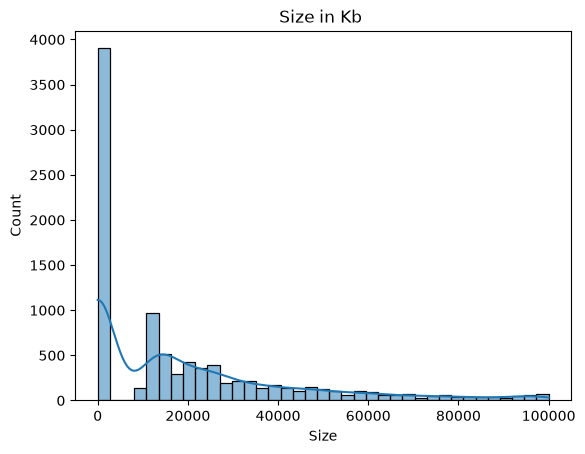

In [23]:
sns.histplot(Data['Size'],kde=True)
plt.title('Size in Kb ')

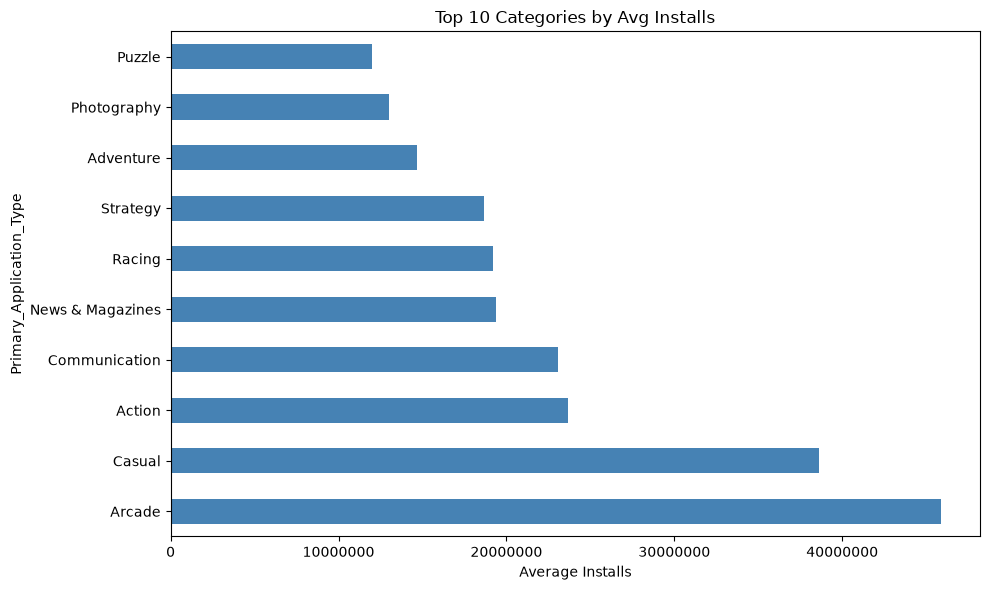

In [68]:
Top_Cat = Data.groupby('Primary_Application_Type')['Installs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
Top_Cat.plot(kind='barh', color='steelblue')
plt.title('Top 10 Categories by Avg Installs')
plt.xlabel('Average Installs')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

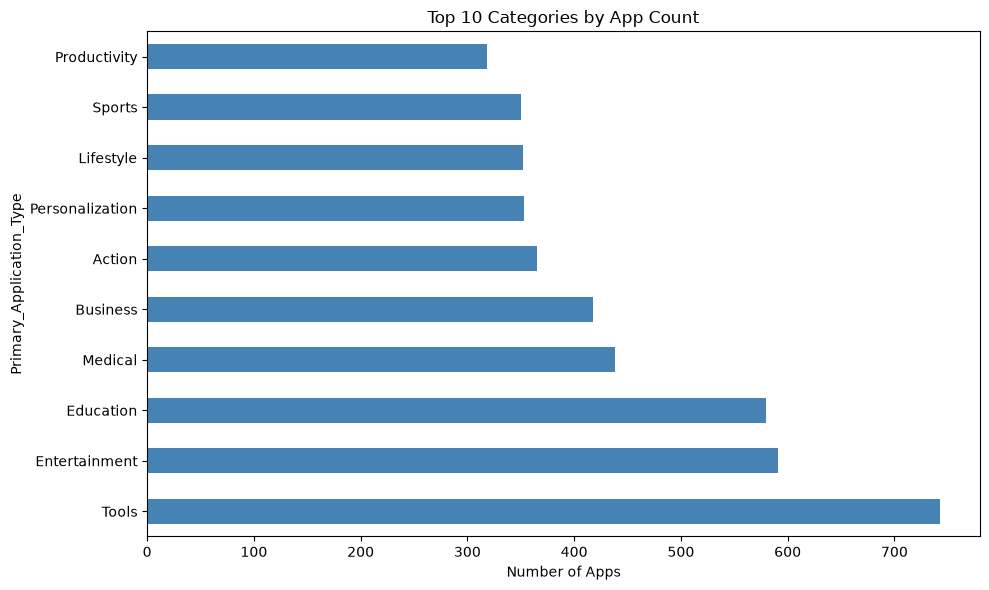

In [69]:
Top_Counts = Data['Primary_Application_Type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
Top_Counts.plot(kind='barh', color='steelblue')
plt.title('Top 10 Categories by App Count')
plt.xlabel('Number of Apps')
plt.tight_layout()
plt.show()

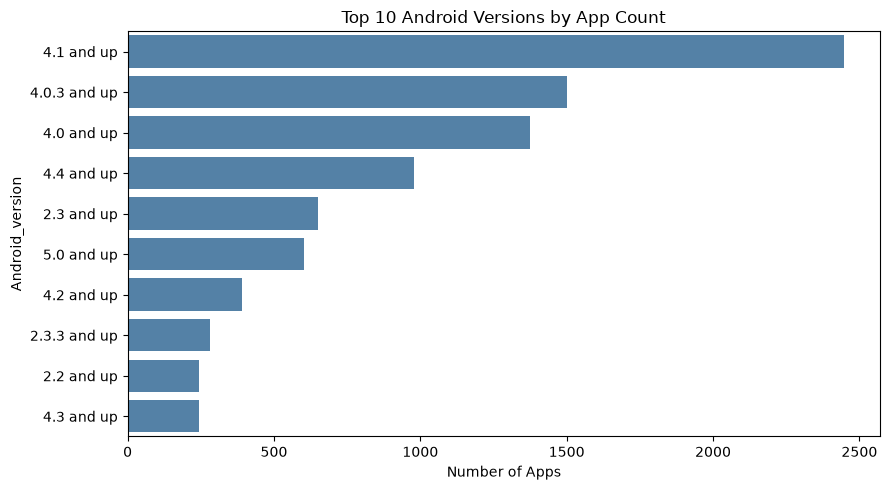

In [38]:
version_counts = Data['Android_version'].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=version_counts.values, y=version_counts.index, color='steelblue')
plt.xlabel('Number of Apps')
plt.title('Top 10 Android Versions by App Count')
plt.tight_layout()
plt.show()

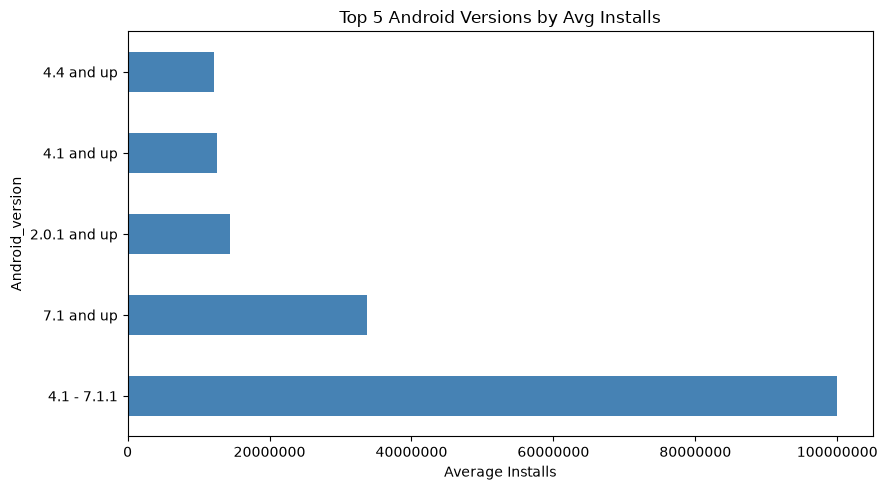

In [70]:
Avg_Installs = Data.groupby('Android_version')['Installs'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(9, 5))
Avg_Installs.plot(kind='barh', color='steelblue')
plt.title('Top 5 Android Versions by Avg Installs')
plt.xlabel('Average Installs')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

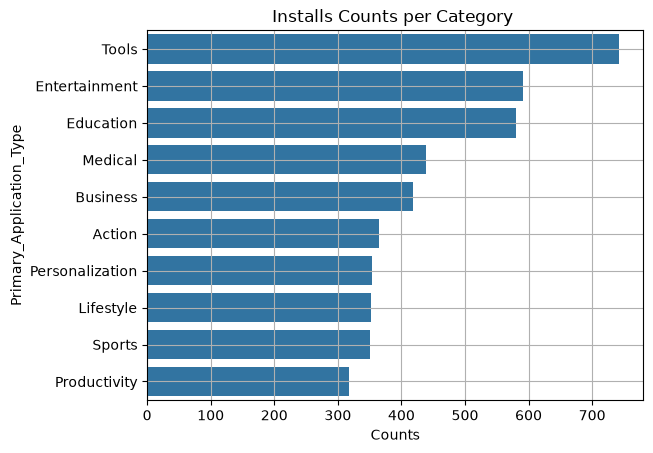

In [47]:
Type_Counts = Data['Primary_Application_Type'].value_counts().head(10)
sns.barplot(x=Type_Counts.values,y=Type_Counts.index)
plt.title('Installs Counts per Category ')
plt.xlabel('Counts')
plt.grid(True)

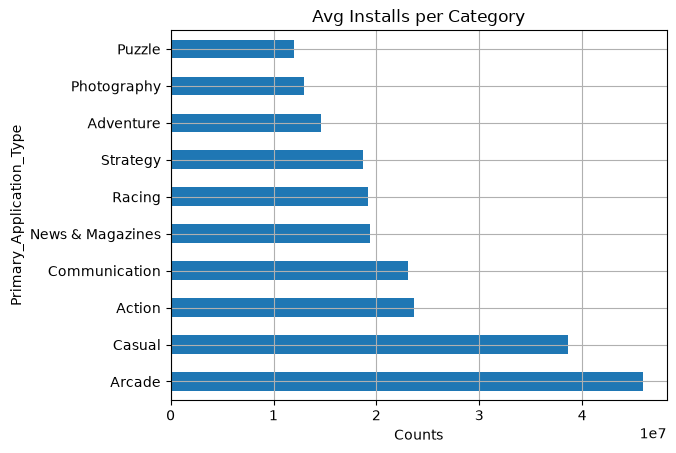

In [50]:
Avg_Installs_Cat = Data.groupby('Primary_Application_Type')['Installs'].mean().sort_values(ascending=False).head(10)
Avg_Installs_Cat.plot(kind='barh')
plt.title('Avg Installs per Category')
plt.xlabel('Counts')
plt.grid(True)

In [51]:
Data

,App,Rating,Reviews,Size,Price,Content Rating,Subscription_Type,Year,Month,Day,Application_Type,Android_version,Primary_Application_Type,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,19000.0,0.0,Everyone,0,2018,1,7,Art & Design,4.0.3 and up,Art & Design,10000
1,Coloring book moana,3.9,967,14000.0,0.0,Everyone,0,2018,1,15,Art & Design;Pretend Play,4.0.3 and up,Art & Design,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,8.7,0.0,Everyone,0,2018,8,1,Art & Design,4.0.3 and up,Art & Design,5000000
3,Sketch - Draw & Paint,4.5,215644,25000.0,0.0,Teen,0,2018,6,8,Art & Design,4.2 and up,Art & Design,50000000
4,Pixel Draw - Number Art Coloring Book,4.3,967,2.8,0.0,Everyone,0,2018,6,20,Art & Design;Creativity,4.4 and up,Art & Design,100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9457,FR Calculator,4.0,7,2.6,0.0,Everyone,0,2017,6,18,Education,4.1 and up,Education,500
9458,FR Forms,4.3,0,9.6,0.0,Everyone,0,2016,9,29,Business,4.0 and up,Business,10
9459,Sya9a Maroc - FR,4.5,38,53000.0,0.0,Everyone,0,2017,7,25,Education,4.1 and up,Education,5000
9460,Fr. Mike Schmitz Audio Teachings,5.0,4,3.6,0.0,Everyone,0,2018,7,6,Education,4.1 and up,Education,100


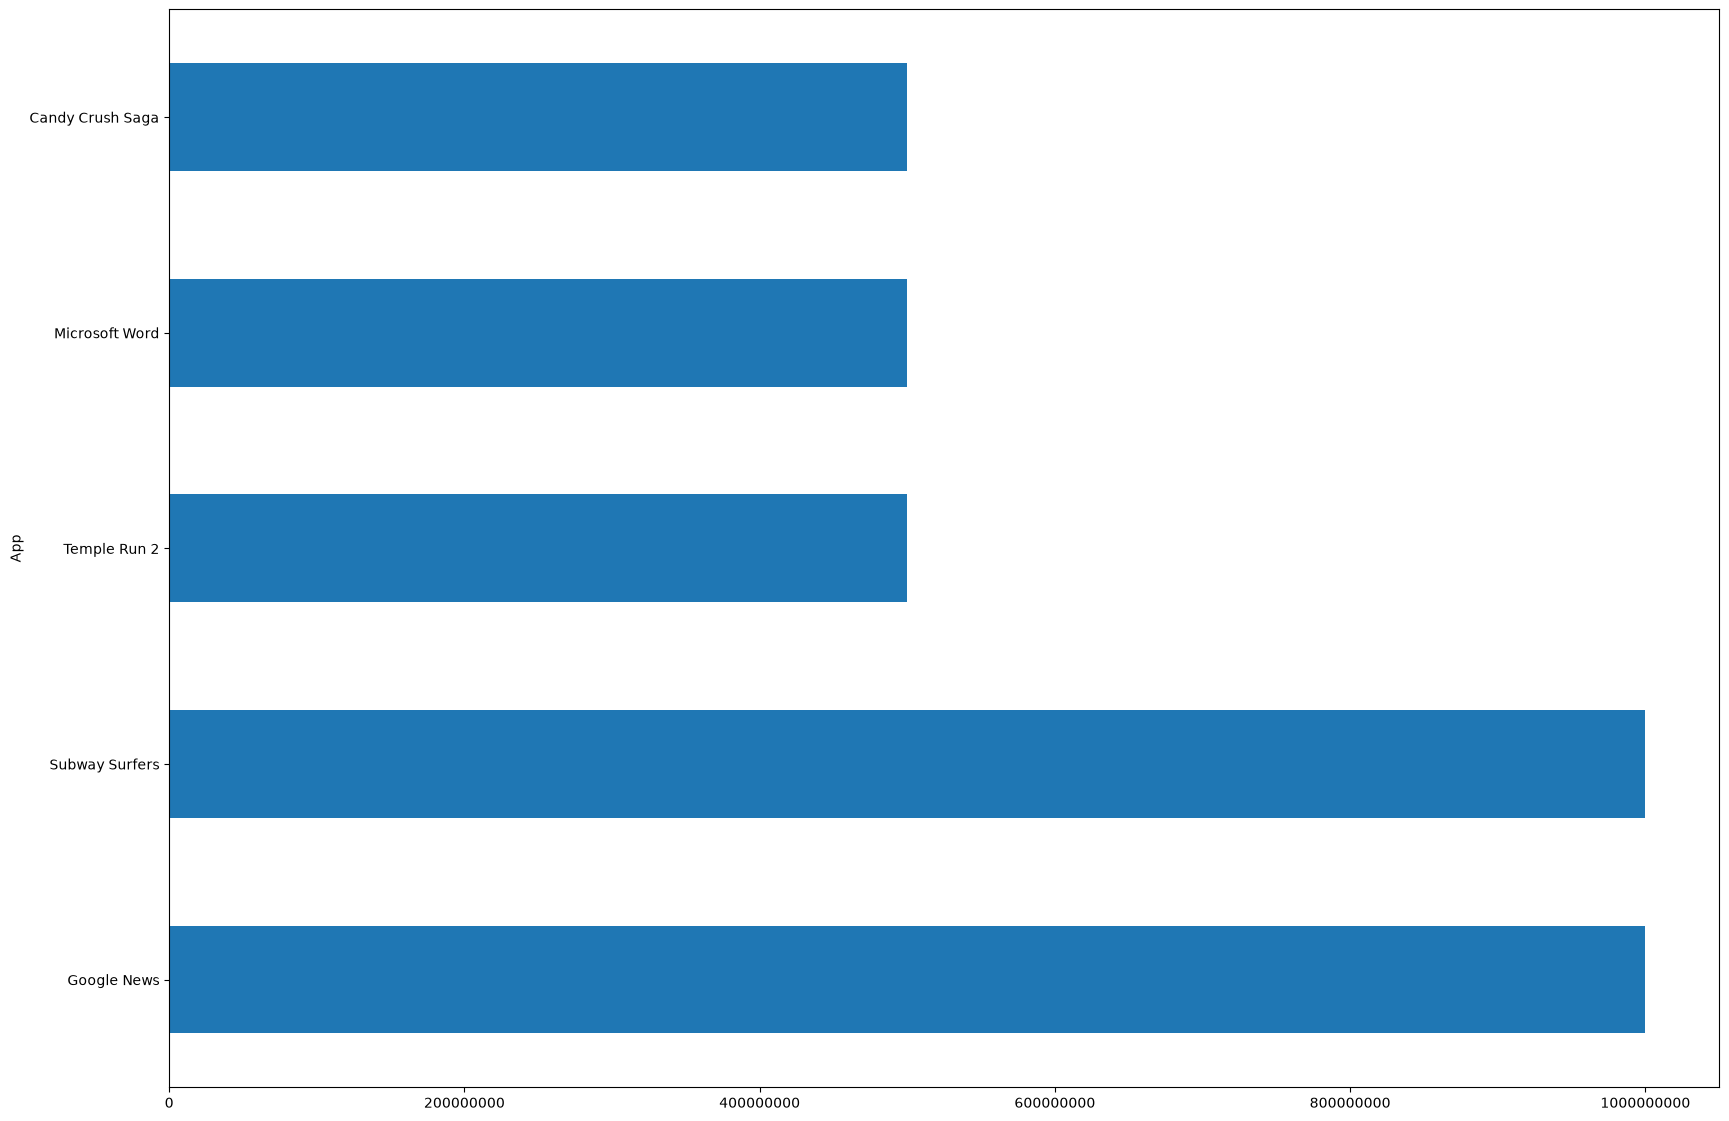

In [71]:
# Top Apps
Top_Apps = Data.groupby('App')['Installs'].max().sort_values(ascending=False).head(5)




plt.figure(figsize=(20,14))
Top_Apps.plot(kind='barh')
plt.ticklabel_format(style='plain',axis='x')

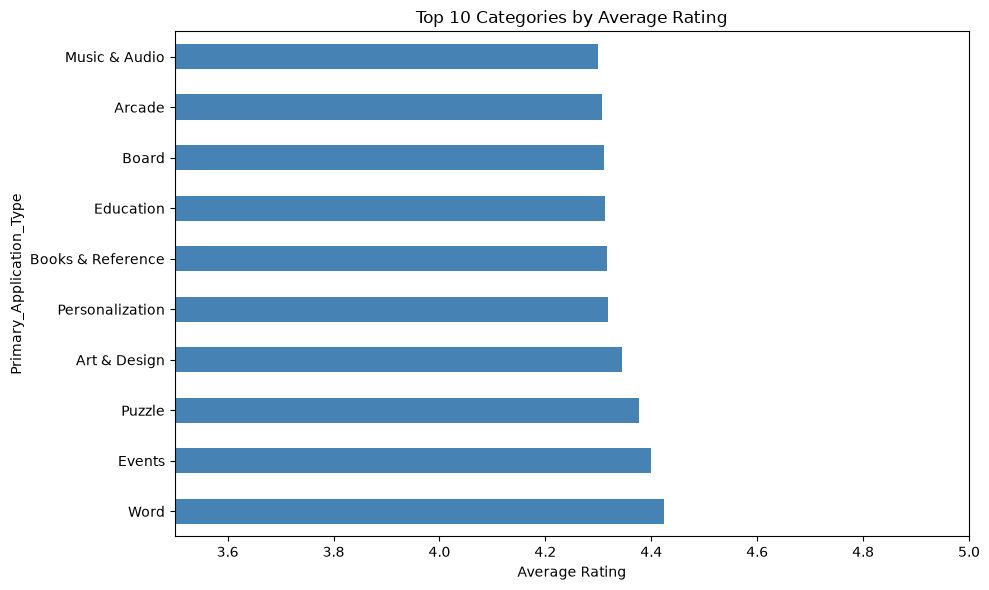

In [72]:
# Average Rating for Each Category
Avg_Rating = Data.groupby('Primary_Application_Type')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
Avg_Rating.plot(kind='barh', color='steelblue')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.xlim(3.5, 5)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Avg Installs: Free vs Paid')

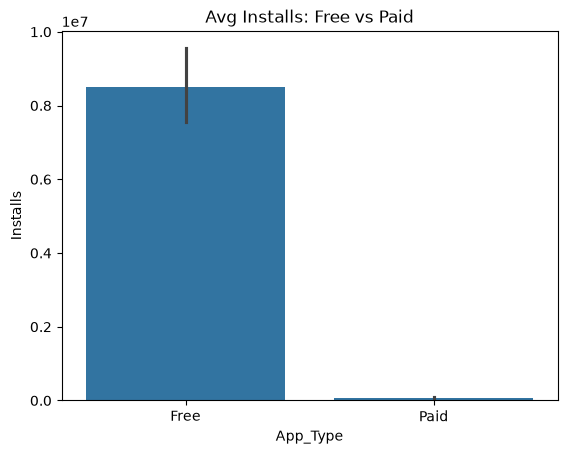

In [60]:
# This is one of the strongest insights in the dataset
Data['App_Type'] = Data['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')
sns.barplot(data=Data, x='App_Type', y='Installs')
plt.title('Avg Installs: Free vs Paid')

<Axes: xlabel='Rating_Group', ylabel='Installs'>

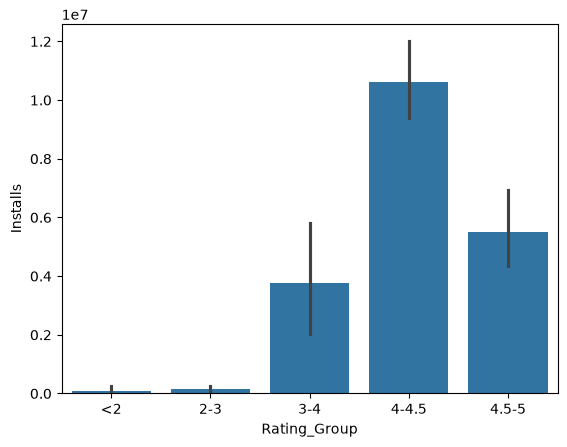

In [61]:
# The 4.0–4.5 sweet spot insight is very compelling
bins = [0, 2, 3, 4, 4.5, 5]
labels = ['<2', '2-3', '3-4', '4-4.5', '4.5-5']
Data['Rating_Group'] = pd.cut(Data['Rating'], bins=bins, labels=labels)
sns.barplot(data=Data, x='Rating_Group', y='Installs', order=labels)

Text(0.5, 1.0, 'Avg Installs by Release Month')

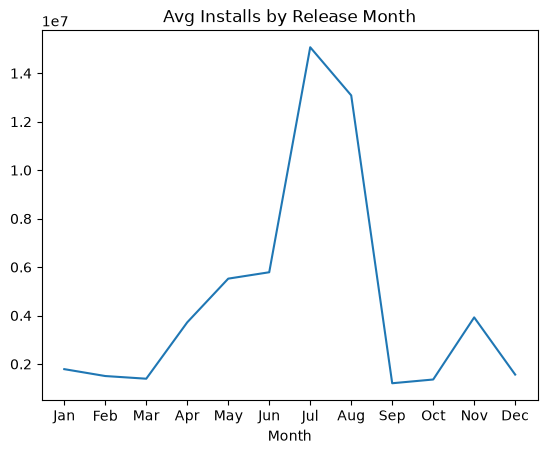

In [62]:
# July/August release = more installs finding is valuable
monthly = Data.groupby('Month')['Installs'].mean()
sns.lineplot(x=monthly.index, y=monthly.values)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Avg Installs by Release Month')

Text(0.5, 1.0, 'Reviews vs Installs (log scale)')

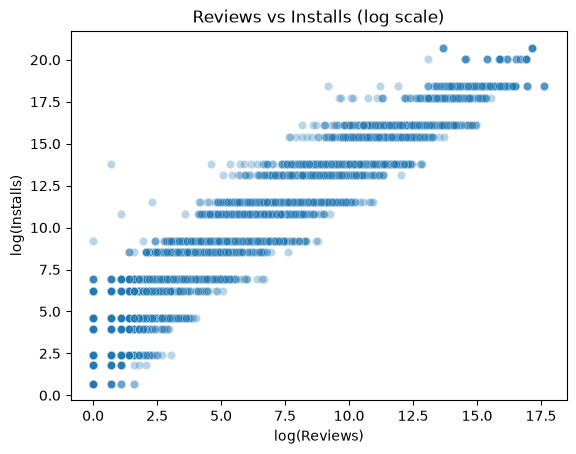

In [63]:
# Most important correlation (0.63) — must be visualized
sns.scatterplot(data=Data, x=np.log1p(Data['Reviews']), y=np.log1p(Data['Installs']), alpha=0.3)
plt.xlabel('log(Reviews)')
plt.ylabel('log(Installs)')
plt.title('Reviews vs Installs (log scale)')

Text(0.5, 1.0, 'App Count by Install Range')

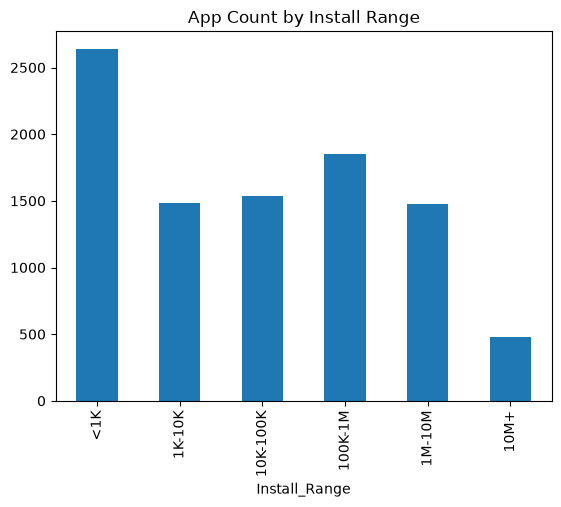

In [64]:
bins = [0,1000,10000,100000,1000000,10000000,float('inf')]
labels = ['<1K','1K-10K','10K-100K','100K-1M','1M-10M','10M+']
Data['Install_Range'] = pd.cut(Data['Installs'], bins=bins, labels=labels)
Data['Install_Range'].value_counts().sort_index().plot(kind='bar')
plt.title('App Count by Install Range')

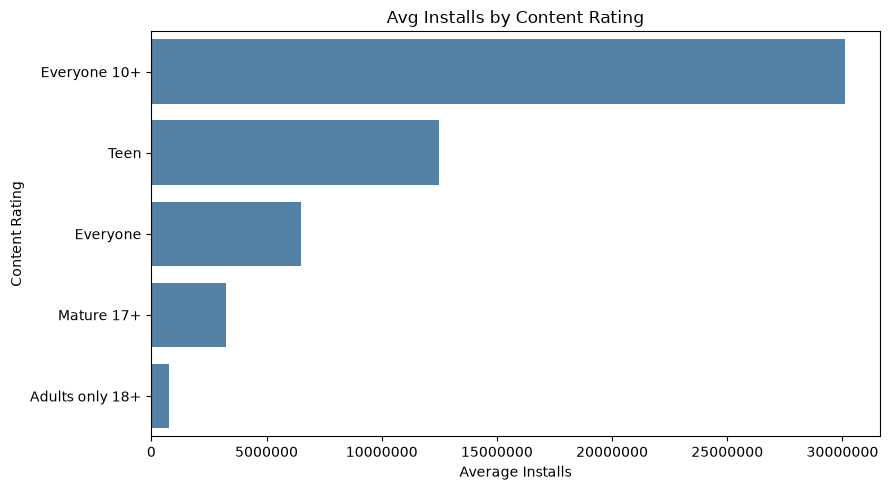

In [73]:
cr_installs = Data.groupby('Content Rating')['Installs'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cr_installs.values, y=cr_installs.index, color='steelblue')
plt.title('Avg Installs by Content Rating')
plt.xlabel('Average Installs')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()